In [48]:
from skimage import feature
from skimage import exposure
from skimage import io
from skimage import color
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [61]:
image = io.imread('steve.jpg')
image_gray = color.rgb2gray(image)

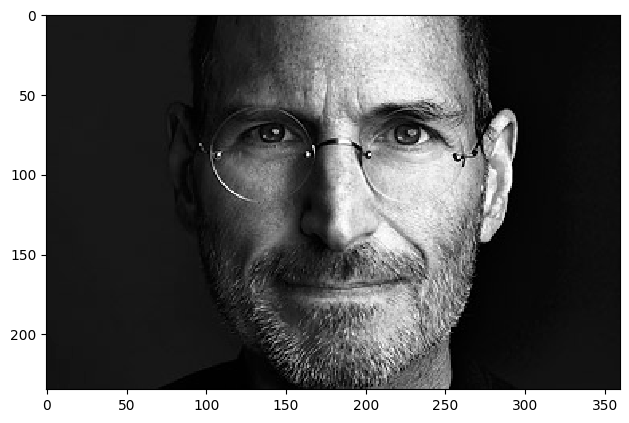

In [62]:
io.imshow(image_gray)

In [65]:
fv,hog_image = feature.hog(image_gray,orientations=9,pixels_per_cell=(8,8),
                           cells_per_block=(2,2),block_norm="L1",visualize=True)

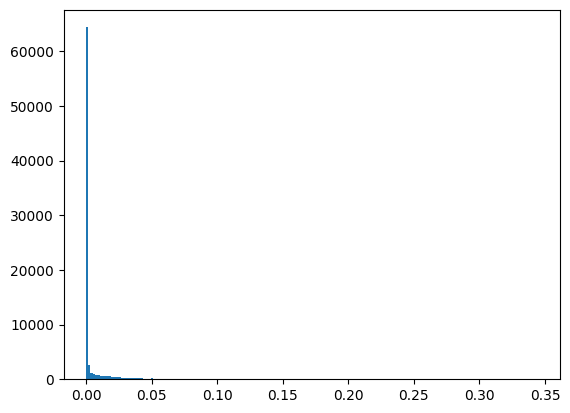

In [67]:
plt.hist(hog_image.flatten(),bins=256)
plt.show()

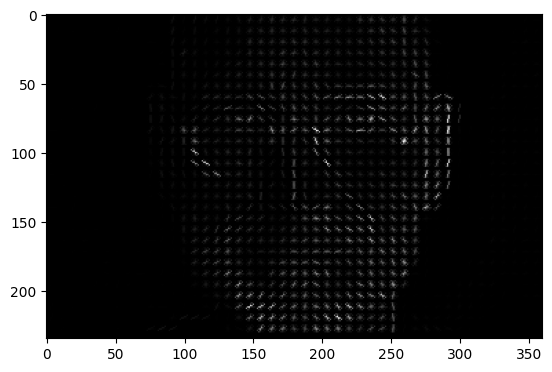

In [69]:
image_hog = exposure.rescale_intensity(hog_image,in_range=(0,0.05),out_range=(0,255))
plt.imshow(hog_image,cmap='gray')

In [53]:
hog = cv2.HOGDescriptor()

In [54]:
hog

<HOGDescriptor 0000019F9ABE6330>

In [55]:
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

In [56]:
location, confidence = hog.detectMultiScale(image)

In [57]:
location

array([[427,  18, 115, 229],
       [107, 122,  72, 144]])

In [58]:
confidence

array([1.05819629, 0.22497915])

In [59]:
for i in location:
    cv2.rectangle(image,(i[0],i[1]),(i[0]+i[2],i[1]+i[3]),(255,0,0),2)

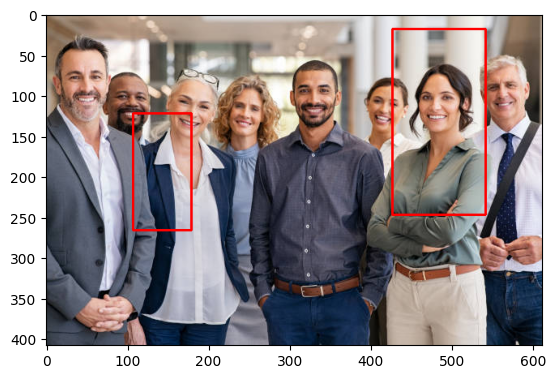

In [60]:
plt.imshow(image)